# TP: Measuring raw camera calibration accuracy

### Name: **Eliott Vigier**

The objective of this TP is to perform a simple camera calibration, and measuring its accuracy.

We will go through the following steps:
- Import a raw image containing a ColorChecker chart
- Extract values from color patches in "linear raw RGB" device colorspace
- Find reference color patch values in CIE-XYZ colorspace
- Find a linear 3x3 color calibration matrix
- Perform color rendering and gamma encoding
- Assess the quality of the calibration
- Compare the raw image to the JPEG image produced by the same sensor

The purpose of the TP is to introduce the basic concept of calibration to reach the fidelity of color rendering and to assess it using a perceptually uniform color space.

Answer the 8 questions below and then export the notebook with the answers using the menu option File->Download .ipynb. **[Then submit your solution here!](https://docs.google.com/forms/d/e/1FAIpQLScZqOU9T5Fuy021Z5-RXmmXFddjrnEyYX0gLsnPJ3EtV4akkg/viewform)**

Install necessary modules:

In [1]:
!pip install colour-science rawpy opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 11.0 MB/s eta 0:00:00


Import necessary modules:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import rawpy
import colour
import cv2

In [3]:
# The following lines install the necessary packages in the colab environment
try:
    from google.colab import files
    !pip install -q hdf5storage

    !rm -fr IspPipeline
    !git clone -b main --single-branch --quiet https://github.com/DXOMARK-OCTO/IspPipeline
    !cp -r IspPipeline/* .

except ImportError:
    # %matplotlib notebook
    pass

%matplotlib inline

import fastisp

# Helper function for displaying images
def imshow(im, **kwargs):
  im = im / im.max()
  plt.figure(figsize=(8, 8))
  plt.imshow(im, **kwargs)
  plt.axis('off')
  plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 2.6 MB/s eta 0:00:00


# Gathering measured data

In this section we will:

- Import a raw image of a ColorChecker chart from a DNG raw file
- Extract linear RGB values measured by the sensor from patches

[DNG](https://helpx.adobe.com/camera-raw/digital-negative.html) (_Digital NeGative_) is a universal file format developped by Adobe, containing the raw data from the sensor as well as some metadata useful to transform the raw data into a viewable image.

The [ColorChecker](https://en.wikipedia.org/wiki/ColorChecker) is a traditional chart for performing color calibration and measurements on image sensors, containing a total of 24 color and gray patches.


Open the DNG image:

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
filename = "Portrait_6500K_100Lux"
raw = rawpy.imread(rf"./OppoFindX3Pro/Portrait/{filename}.dng")

Extract each channel ($R$, $G_1$, $B$, $G_2$) from the raw image data:

In [6]:
imageB = raw.raw_image[::2, ::2]
imageG2 = raw.raw_image[::2, 1::2]
imageR = raw.raw_image[1::2, 1::2]
imageG1 = raw.raw_image[1::2, ::2]

Let's display these channels:

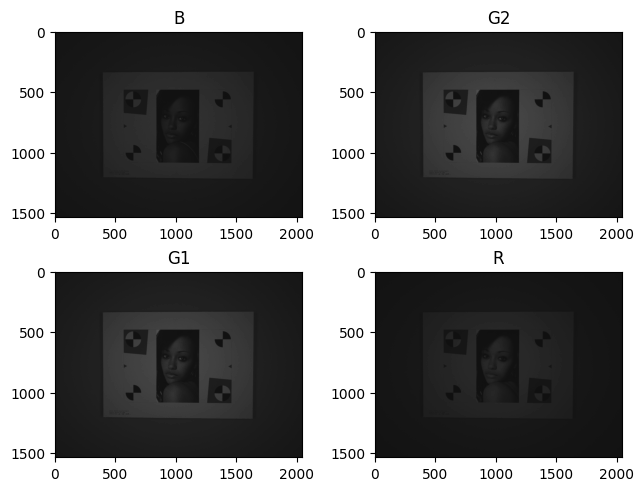

In [7]:
fig, axes = plt.subplots(nrows=2, ncols=2, constrained_layout=True)
axes[0, 0].imshow(imageB, vmin=0, vmax=1024, cmap="gray")
axes[0, 0].set_title("B")
axes[0, 1].imshow(imageG2, vmin=0, vmax=1024, cmap="gray")
axes[0, 1].set_title("G2")
axes[1, 1].imshow(imageR, vmin=0, vmax=1024, cmap="gray")
axes[1, 1].set_title("R")
axes[1, 0].imshow(imageG1, vmin=0, vmax=1024, cmap="gray")
axes[1, 0].set_title("G1")
fig.show()

Find coordinates of patch ROIs from the ColorChecker:

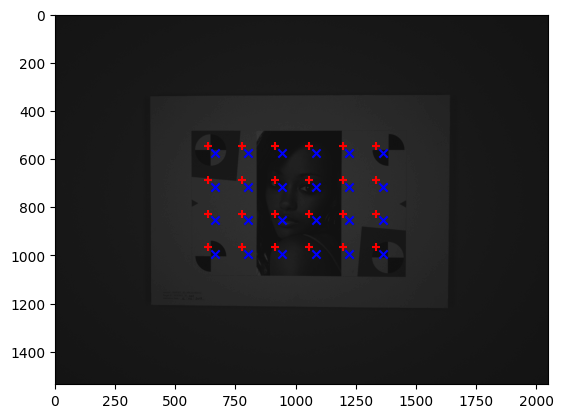

In [8]:
coordinates = ((x0, y0), (x1, y1)) = np.array([
    [580, 490],
    [1420, 1050],
])

rectangles = np.round(np.array([
    [
        [x0 + (0.4+i)/6*(x1-x0), y0 + (0.4+j)/4*(y1-y0)],
        [x0 + (0.6+i)/6*(x1-x0), y0 + (0.6+j)/4*(y1-y0)]
    ] for j in range(4) for i in range(6)
])).astype(int)

plt.imshow(imageB, vmin=0, vmax=1024, cmap="gray")
plt.scatter(*rectangles[:, 0, :].T, marker="+", color="red")
plt.scatter(*rectangles[:, 1, :].T, marker="x", color="blue")
plt.show()

Extract average RGB values from these patches:

In [9]:
patchesR = [np.mean(imageR[py0:py1, px0:px1]) for ((px0, py0), (px1, py1)) in rectangles]
patchesG = [np.mean(imageG1[py0:py1, px0:px1]) for ((px0, py0), (px1, py1)) in rectangles]
patchesB = [np.mean(imageB[py0:py1, px0:px1]) for ((px0, py0), (px1, py1)) in rectangles]
raw_rgb = np.vstack((patchesR, patchesG, patchesB)).T

print("Raw RGB values of gray patches:")
raw_rgb[18:, :]

Raw RGB values of gray patches:


array([[  97.65433673,  141.23469388,  111.05484694],
       [ 155.85969388,  261.90688776,  183.95663265],
       [ 139.91071429,  169.87882653,  113.18112245],
       [ 111.17346939,  119.95408163,   87.10969388],
       [ 156.11989796,  259.60714286,  183.06760204],
       [  67.04591837,   70.65688776,   68.15561224]])

Let's explore some of the metadata.

In [10]:
print(f"Bayer pattern: {raw.raw_pattern.tolist()}")
print(f"Black level: {raw.black_level_per_channel}")
print(f"White level: {raw.white_level}")

Bayer pattern: [[2, 3], [1, 0]]
Black level: [64, 64, 64, 64]
White level: 1023


In [11]:
measured_rgb = (raw_rgb - raw.black_level_per_channel[0]) / (raw.white_level - raw.black_level_per_channel[0])

print("Measured RGB values of gray patches:")
measured_rgb[18:, :]

Measured RGB values of gray patches:


array([[ 0.03509316,  0.0805367 ,  0.04906658],
       [ 0.09578696,  0.20636797,  0.12508512],
       [ 0.07915612,  0.11040545,  0.05128376],
       [ 0.04919027,  0.05834628,  0.0240977 ],
       [ 0.09605829,  0.20396991,  0.12415808],
       [ 0.00317614,  0.00694149,  0.00433328]])

> **Question 1**:
>
> What colorspace are RGB values in `raw_rgb` in? What is the expected range of these values?
>
> The RGB values in raw_rgb are in an affine colorspace, not fully linear due to black and white level adjustmentsadjustments, so they can exceed standard ranges (higher than 255).


>
> What colorspace are RGB values in `measured_rgb` in? What is the expected range of these values?
>
> The RGB values in measured_rgb are linear with respect to luminance/photons, ranging from 0 to 1, where 0 is no light and 1 is maximum luminance.




# Interlude: Measuring the noise response of the sensor

Let's plot the SNR for one green channel of the gray patches, as a function of the grey level in percentage:

In [12]:
stdG = np.array([np.std(imageG1[py0:py1, px0:px1]) for ((px0, py0), (px1, py1)) in rectangles])
SNRG = ( raw_rgb[18:, 1] - raw.black_level_per_channel[0] ) / stdG[18:]

GrayLevels = measured_rgb[18:, 1]

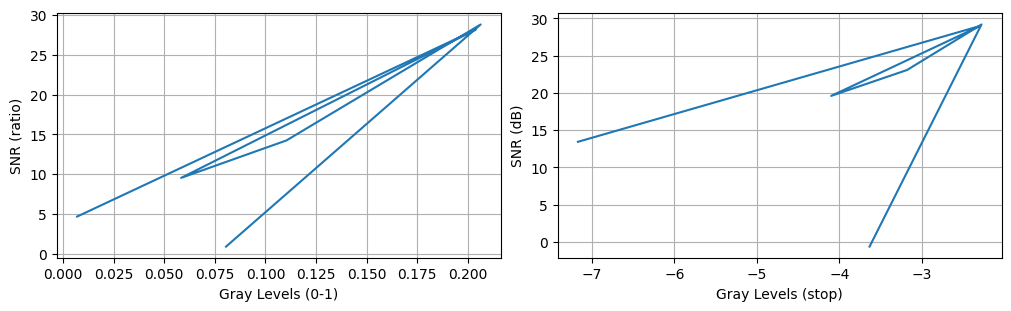

In [13]:
fig, (ax1, ax2) = plt.subplots(ncols=2, constrained_layout=True, figsize=(10, 3))

ax1.plot(GrayLevels, SNRG)
ax1.set_ylabel('SNR (ratio)')
ax1.set_xlabel('Gray Levels (0-1)')
ax1.grid(True)

ax2.plot(np.log2(GrayLevels), 20*np.log10(SNRG))
ax2.set_ylabel('SNR (dB)')
ax2.set_xlabel('Gray Levels (stop)')
ax2.grid(True)

fig.show()


> **Question 2**: Can you give a rough estimate the full well capacity (in photons) of this sensor? How does it compare with other sensors for which we've estimated full well capacities in previous lectures?
>
> It seems that we have a slope of around 3dB per stop around gray levels of 0.125, equivalent to -3 stops relative to saturation.
>
> We assume we're using an ideal sensor, with the following assumptions:
> - The photon to electron conversion is 100% efficient.
> - The sensor is perfectly linear
> - The noise regime is purely photonic at this grey level

The SNR at a gray level of 0.125 is 16 (in ratio)
$$
\text{SNR (dB)} = 20 \cdot \log_{10}(16) \approx 24 \, \text{dB}
$$
Since we are 3 stops below saturation and have a slope of 3 dB per stop, we add 9 dB to the SNR at gray level 0.125 :
$$
\text{SNR at saturation} = 24 \, \text{dB} + 9 \, \text{dB} = 33 \, \text{dB}
$$

$$
\text{SNR (ratio)} = 10^{\frac{33}{20}} \approx 44.67
$$

$$
\text{SNR} = \sqrt{\text{FW}}
$$

$$
\text{FW} = (44.67)^2 \approx 1995 \, \text{photons}
$$

# Gathering reference patch data

The [colour-science](https://www.colour-science.org/) library contains reference values in xyY coordinates from various sources, measured under the D50 illuminant.


In [14]:
colour.CCS_COLOURCHECKERS["BabelColor Average"].data

{'dark skin': array([ 0.4325,  0.3788,  0.1034]),
 'light skin': array([ 0.4191,  0.3748,  0.3525]),
 'blue sky': array([ 0.2761,  0.3004,  0.1847]),
 'foliage': array([ 0.37  ,  0.4501,  0.1335]),
 'blue flower': array([ 0.302 ,  0.2877,  0.2324]),
 'bluish green': array([ 0.2856,  0.391 ,  0.4174]),
 'orange': array([ 0.5291,  0.4075,  0.3117]),
 'purplish blue': array([ 0.2339,  0.2155,  0.114 ]),
 'moderate red': array([ 0.5008,  0.3293,  0.1979]),
 'purple': array([ 0.3326,  0.2556,  0.0644]),
 'yellow green': array([ 0.3989,  0.4998,  0.4435]),
 'orange yellow': array([ 0.4962,  0.4428,  0.4358]),
 'blue': array([ 0.204 ,  0.1696,  0.0579]),
 'green': array([ 0.327 ,  0.5033,  0.2307]),
 'red': array([ 0.5709,  0.3298,  0.1268]),
 'yellow': array([ 0.4694,  0.4732,  0.6081]),
 'magenta': array([ 0.4177,  0.2704,  0.2007]),
 'cyan': array([ 0.2151,  0.3037,  0.1903]),
 'white 9.5 (.05 D)': array([ 0.3488,  0.3628,  0.9129]),
 'neutral 8 (.23 D)': array([ 0.3451,  0.3596,  0.5885])

In [15]:
# Chromaticity coordinates in CIE-xyY space
cc_xyY = np.array([v for v in colour.CCS_COLOURCHECKERS["BabelColor Average"].data.values()])

# Chromaticity in CIE-XYZ space
cc_XYZ = colour.xyY_to_XYZ(cc_xyY)

print(cc_XYZ)

[[ 0.11805834  0.1034      0.05150892]
 [ 0.39416422  0.3525      0.19383738]
 [ 0.16975922  0.1847      0.26038765]
 [ 0.10974228  0.1335      0.05335848]
 [ 0.24395134  0.2324      0.33143455]
 [ 0.30488348  0.4174      0.3452357 ]
 [ 0.40471281  0.3117      0.04849517]
 [ 0.12373364  0.114       0.29126868]
 [ 0.30096666  0.1979      0.1021051 ]
 [ 0.08380063  0.0644      0.10375556]
 [ 0.35396589  0.4435      0.08988906]
 [ 0.48835583  0.4358      0.06003568]
 [ 0.06964387  0.0579      0.21384764]
 [ 0.14988854  0.2307      0.07778619]
 [ 0.21949703  0.1268      0.03817841]
 [ 0.60321669  0.6081      0.07376361]
 [ 0.31003103  0.2007      0.2315027 ]
 [ 0.13478278  0.1903      0.30152242]
 [ 0.87767233  0.9129      0.72569008]
 [ 0.56477016  0.5885      0.48327044]
 [ 0.34507994  0.3595      0.29681281]
 [ 0.18315564  0.1912      0.15838328]
 [ 0.08547928  0.0893      0.07494108]
 [ 0.030869    0.032       0.02689257]]


> **Question 3:** What is the range of these values? Are white and black patches of the ColorChecker exactly white and black?


The y values are normalized between 0 and 1, representing luminance. The x and z values can vary depending on the light source, with 0 as a minimum.

No, the white and black patches are not exactly pure white or black. They represent approximate colors under standard lighting conditions, influenced by the characteristics of the light source.


# Finding the calibration matrix

Thanks to these XYZ references, we will find the best matrix that transform the raw data (proportionnal to luminance in the scene) to XYZ, through least mean square minimization.

In [16]:
# Build a linear system
A = []
b = []
for measured_rgb_patch, reference_xyz_patch in zip(measured_rgb, cc_XYZ):
  A.append(measured_rgb_patch.tolist() + [0, 0, 0, 0, 0, 0])
  A.append([0, 0, 0] + measured_rgb_patch.tolist() + [0, 0, 0])
  A.append([0, 0, 0, 0, 0, 0] + measured_rgb_patch.tolist())
  b.extend(reference_xyz_patch)

A = np.array(A)
b = np.array(b)

# ... and solve it!
Mvalues, resid, _, _ = np.linalg.lstsq(A, b, rcond=None)
M = Mvalues.reshape((3, 3))

print(f"Residual:{resid}")
print(f"Calibration Matrix:\n{M}")

Residual:[ 3.1409493]
Calibration Matrix:
[[ -4.65406466  17.76160576 -23.11365874]
 [ -7.76898474  22.47476732 -28.45357141]
 [-13.57097867  26.83153659 -31.74691763]]


The [colour-science](https://www.colour-science.org/) library provides useful tools to visualize color patches! Let's look at the results.

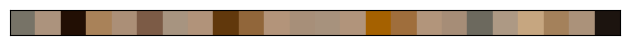

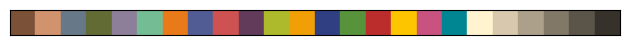

In [17]:
rgb = colour.XYZ_to_sRGB((M @ measured_rgb.T).T)
swatches = [colour.plotting.common.ColourSwatch(x) for x in rgb]
colour.plotting.plot_multi_colour_swatches(swatches, coloums=6)
plt.show()

rgb = colour.XYZ_to_sRGB(cc_XYZ)
swatches = [colour.plotting.common.ColourSwatch(x) for x in rgb]
colour.plotting.plot_multi_colour_swatches(swatches, coloums=6)
plt.show()

> **Question 4:** What is the goal of the `colour.XYZ_to_sRGB` function? Why are the gray patches slightly yellow?


The function converts CIE-XYZ to sRGB for display. The gray patches appear slightly yellow due to a white point mismatch: D50 (ColorChecker) vs. D55 (display).

# Finding the calibration matrix under a different illuminant

Let's generate reference values under another illuminant: [D65](https://en.wikipedia.org/wiki/Illuminant_D65) in order to display the resulting image.

While we could go in the lab and measure patches with a spectrometer under that illuminant, it is possible to find an estimate of a XYZ color under an illuminant given the XYZ color coordinates under another illuminant, using "chromatic adaptation" models. The [Bradford adaptation](http://www.brucelindbloom.com/index.html?Eqn_ChromAdapt.html) is one of the chromatic adaptation models that we propose to use here.

In [18]:
cc_xyY_d50 = np.array([v for v in colour.CCS_COLOURCHECKERS["BabelColor Average"].data.values()])
XYZ_wr_d65 = colour.xy_to_XYZ(colour.CCS_ILLUMINANTS["cie_2_1931"]["D65"])
XYZ_w_d50 = colour.xy_to_XYZ(colour.CCS_ILLUMINANTS["cie_2_1931"]["D50"])
m_d50_to_d65 = colour.adaptation.matrix_chromatic_adaptation_VonKries(XYZ_w_d50, XYZ_wr_d65, "Bradford")
cc_XYZ_d50 = colour.xyY_to_XYZ(cc_xyY_d50)
cc_XYZ_d65 = (m_d50_to_d65 @ cc_XYZ_d50.T).T

print(cc_XYZ_d65)

[[ 0.11367164  0.10216807  0.067859  ]
 [ 0.38073324  0.34891967  0.25549944]
 [ 0.17440606  0.18720906  0.34471351]
 [ 0.1051476   0.13284377  0.0695999 ]
 [ 0.24868724  0.23477596  0.43916727]
 [ 0.30350611  0.42018688  0.45448426]
 [ 0.38256031  0.30435439  0.06310772]
 [ 0.13401642  0.1177579   0.38667971]
 [ 0.28945355  0.19348819  0.13548479]
 [ 0.08514523  0.06484947  0.13774409]
 [ 0.33364715  0.43978245  0.11484894]
 [ 0.46034252  0.42756472  0.07694581]
 [ 0.0787333   0.06100262  0.28416582]
 [ 0.14280639  0.23039038  0.10059871]
 [ 0.20920983  0.12264368  0.05089378]
 [ 0.56697758  0.59861721  0.09308991]
 [ 0.30623523  0.19878174  0.30768514]
 [ 0.14345981  0.19472284  0.39889227]
 [ 0.86341261  0.91239506  0.95751959]
 [ 0.55660076  0.58852863  0.63781236]
 [ 0.34018697  0.3595489   0.39174647]
 [ 0.18060313  0.19124766  0.20904204]
 [ 0.0843512   0.08934444  0.09892032]
 [ 0.03045657  0.03200997  0.03550083]]


In [19]:
# Build a linear system
A = []
b = []
for measured_rgb_patch, reference_xyz_patch in zip(measured_rgb, cc_XYZ_d65):
  A.append(measured_rgb_patch.tolist() + [0, 0, 0, 0, 0, 0])
  A.append([0, 0, 0] + measured_rgb_patch.tolist() + [0, 0, 0])
  A.append([0, 0, 0, 0, 0, 0] + measured_rgb_patch.tolist())
  b.extend(reference_xyz_patch)

A = np.array(A)
b = np.array(b)

# ... and solve it!
Mvalues, resid, _, _ = np.linalg.lstsq(A, b, rcond=None)
M_D65 = Mvalues.reshape((3, 3))

print(f"Residual:{resid}")
print(f"Calibration Matrix for the D65 illuminant:\n{M_D65}")

Residual:[ 3.59632662]
Calibration Matrix for the D65 illuminant:
[[ -5.12587338  18.14895253 -23.43553904]
 [ -8.00015732  22.76009417 -28.75024931]
 [-17.95235421  35.45357407 -41.93612355]]


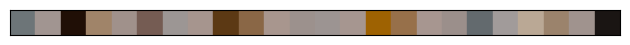

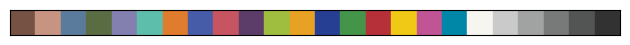

In [20]:
rgb = colour.XYZ_to_sRGB((M_D65 @ measured_rgb.T).T)
swatches = [colour.plotting.common.ColourSwatch(x) for x in rgb]
colour.plotting.plot_multi_colour_swatches(swatches, coloums=6)
plt.show()

rgb = colour.XYZ_to_sRGB(cc_XYZ_d65)
swatches = [colour.plotting.common.ColourSwatch(x) for x in rgb]
colour.plotting.plot_multi_colour_swatches(swatches, coloums=6)
plt.show()

> **Question 5:** In CIE-XYZ, what is the colour of "gray"?
>
>It depends on the illuminant, as "gray" is defined by equal X, Y, and Z values adjusted to the specific white point of the illuminant.

# Applying Calibration

Let's apply the calibration matrix to the image, and observe the results.

(1536, 2048, 3)


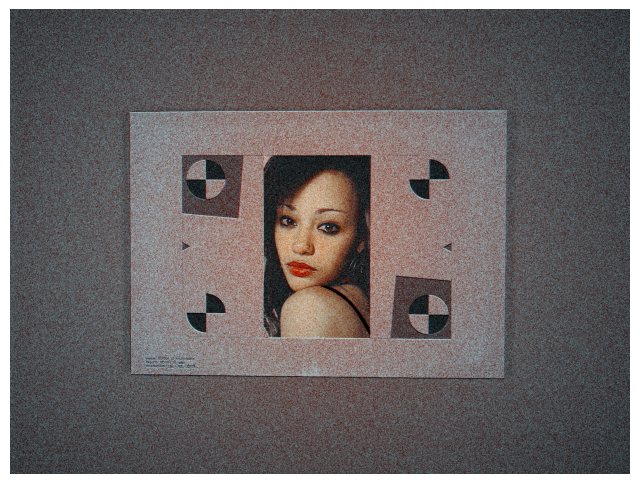

In [21]:
img_raw = (np.dstack([imageR, imageG1, imageB]).astype(np.float32) - raw.black_level_per_channel[0]) / (raw.white_level - raw.black_level_per_channel[0])
img_rgb = np.clip(colour.XYZ_to_sRGB((M_D65 @ img_raw.reshape(-1, 3).T).T.reshape(img_raw.shape)), 0, 1)
print(img_rgb.shape)
img_bgr = cv2.cvtColor(np.array(img_rgb*255,'uint8'), cv2.COLOR_RGB2BGR)
cv2.imwrite("img_rgb.jpg",img_bgr)

imshow(img_rgb)
plt.show()

> **Question 6:** What does the above code do?
>
>The code processes raw sensor data (imageR, imageG1, imageB channels) to produce and save an sRGB image. Starting from a raw format, it normalizes the pixel values, converts the image to the sRGB color space, and outputs a displayable JPEG file (img_rgb.jpg). (It does all the steps bellow)

> Where are all the steps from the processing pipeline introduced in the last TP? Where are the demosaicing, white balance, color rendering and gamma steps?
>
> Demosaicing : Dtacking the channels (R, G1, B).
>
> White Balance : During normalization in the line :
>
> img_raw = (np.dstack([imageR, imageG1, imageB]).astype(np.float32) - raw.black_level_per_channel[0]) / (raw.white_level - raw.black_level_per_channel[0])
>>
> Color Rendering : When applying the color correction matrix and converting to sRGB :

> np.clip(colour.XYZ_to_sRGB((M_D65 @ img_raw.reshape(-1, 3).T).T.reshape(img_raw.shape)), 0, 1)
>>
> Gamma Correction : Implicitly within the colour.XYZ_to_sRGB function.
>



# Comparing to other renderings

Let's load the JPEG files provided by the camera:

In [ ]:
path = r"/content/OppoFindX3Pro/Portrait/Portrait_6500K_100Lux.jpg"
img_jpg = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)[::2, ::2, :]

Let's generate the image from the previous TP:

In [ ]:
cm = raw.color_matrix[0:3,0:3]
print(f"Color Matrix: {cm}")
wb = np.array(raw.camera_whitebalance)
print(f"White Balance: {wb}")

img_isp = fastisp.isp(raw.raw_image, raw.raw_pattern, raw.black_level_per_channel[0], 1.8, wb[:3], cm, raw.white_level)
img_isp = img_isp[::2, ::2, :]

Color Matrix: [[ 1.7879809  -0.80493003  0.01694908]
 [-0.1830969   1.2751694  -0.09207252]
 [-0.0547976  -0.6531928   1.7079904 ]]
White Balance: [ 1.95419848  1.          1.60000002  0.        ]


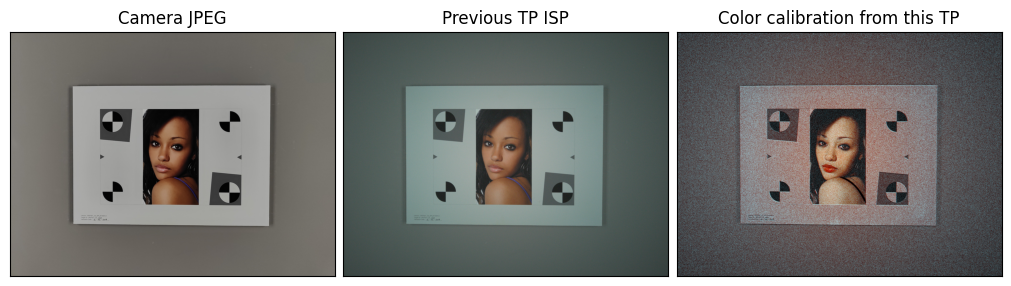

In [ ]:
fig, axes = plt.subplots(ncols=3, constrained_layout=True, figsize=(10, 3))

axes[0].imshow(img_jpg)
axes[0].set_title("Camera JPEG")
axes[1].imshow(img_isp)
axes[1].set_title("Previous TP ISP")
axes[2].imshow(img_rgb)
axes[2].set_title("Color calibration from this TP")

for ax in axes:
  ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.show()

In [ ]:
patchesR = [np.mean(img_jpg[py0:py1, px0:px1,0]/255) for ((px0, py0), (px1, py1)) in rectangles]
patchesG = [np.mean(img_jpg[py0:py1, px0:px1,1]/255) for ((px0, py0), (px1, py1)) in rectangles]
patchesB = [np.mean(img_jpg[py0:py1, px0:px1,2]/255) for ((px0, py0), (px1, py1)) in rectangles]
patches_jpg = np.vstack((patchesR, patchesG, patchesB)).T

patchesR = [np.mean(img_rgb[py0:py1, px0:px1,0]) for ((px0, py0), (px1, py1)) in rectangles]
patchesG = [np.mean(img_rgb[py0:py1, px0:px1,1]) for ((px0, py0), (px1, py1)) in rectangles]
patchesB = [np.mean(img_rgb[py0:py1, px0:px1,2]) for ((px0, py0), (px1, py1)) in rectangles]
patches_rgb = np.vstack((patchesR, patchesG, patchesB)).T

patchesR = [np.mean(img_isp[py0:py1, px0:px1,0]) for ((px0, py0), (px1, py1)) in rectangles]
patchesG = [np.mean(img_isp[py0:py1, px0:px1,1]) for ((px0, py0), (px1, py1)) in rectangles]
patchesB = [np.mean(img_isp[py0:py1, px0:px1,2]) for ((px0, py0), (px1, py1)) in rectangles]
patches_isp = np.vstack((patchesR, patchesG, patchesB)).T

print("Gray patch #21 (JPEG image):")
print(patches_jpg[21])
print("Gray patch #21 (RGB calibration from this TP):")
print(patches_rgb[21])
print("Gray patch #21 (ISP from previous TP):")
print(patches_isp[21])

Gray patch #21 (JPEG image):
[ 0.42176371  0.21811725  0.11787215]
Gray patch #21 (RGB calibration from this TP):
[ 0.60454629  0.47995853  0.37356968]
Gray patch #21 (ISP from previous TP):
[ 0.50924829  0.34380195  0.22892589]


We will use the [CIELAB](https://en.wikipedia.org/wiki/CIELAB_color_space) color space to quantify the differences between the images:

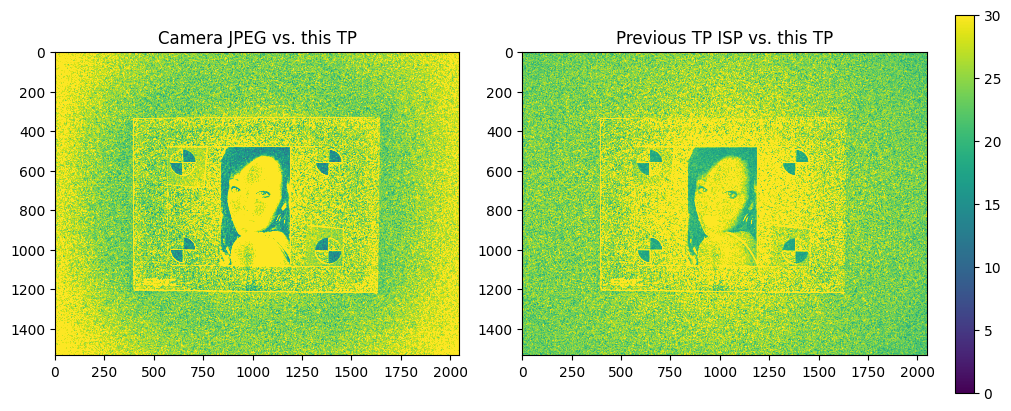

In [ ]:
# @title
fig, (ax_jpg, ax_isp) = plt.subplots(ncols=2, constrained_layout=True, figsize=(10, 4))

deltalab_jpg = colour.XYZ_to_Lab(colour.sRGB_to_XYZ(img_jpg / 255.0)) - colour.XYZ_to_Lab(colour.sRGB_to_XYZ(img_rgb))
deltae_jpg = np.linalg.norm(deltalab_jpg, axis=-1)
im = ax_jpg.imshow(deltae_jpg, vmin=0, vmax=30)
ax_jpg.set_title("Camera JPEG vs. this TP")

deltalab_isp = colour.XYZ_to_Lab(colour.sRGB_to_XYZ(img_isp)) - colour.XYZ_to_Lab(colour.sRGB_to_XYZ(img_rgb))
deltae_isp = np.linalg.norm(deltalab_isp, axis=-1)
im = ax_isp.imshow(deltae_isp, vmin=0, vmax=30)
ax_isp.set_title("Previous TP ISP vs. this TP")

fig.colorbar(im, ax=ax_isp)

plt.show()

Differences on each patch:

In [ ]:
patches_lab_jpg = colour.XYZ_to_Lab(colour.sRGB_to_XYZ(patches_jpg))
patches_lab_rgb = colour.XYZ_to_Lab(colour.sRGB_to_XYZ(patches_rgb))
patches_lab_isp = colour.XYZ_to_Lab(colour.sRGB_to_XYZ(patches_isp))

patches_deltae_rgb = np.linalg.norm(patches_lab_jpg - patches_lab_rgb, axis=-1)
patches_deltae_isp = np.linalg.norm(patches_lab_isp - patches_lab_rgb, axis=-1)

print("DeltaE between camera JPEG and this TP:")
print(patches_deltae_rgb)
print("DeltaE between ISP from previous TP and this TP:")
print(patches_deltae_isp)

DeltaE between camera JPEG and this TP:
[  4.8286721   14.17051445  10.46176467  24.72583685  16.84254064
   9.89936555  12.49258226  16.40077575  13.04863687  16.37225469
  16.65962075  14.62119551  12.56341265  15.15965926  13.99921096
  18.82973963  16.11802409  14.77329972   6.21246815   9.38388725
  22.90835671  27.85042857  14.99534468  11.40465539]
DeltaE between ISP from previous TP and this TP:
[  5.10138334  17.94883308   4.73422286  12.25445608  20.77468039
  15.56348205  16.64890252  20.20547037   7.21197608   4.37552569
  20.13579403  19.01553089  17.10749748  19.28414902  16.81728021
   6.85405084  19.58412449  18.22396401   4.90921318  13.91029261
  16.32792208  14.42049985  17.93331912   3.93304472]


> **Question 7:** How do the 3 tested RGB images compare?
>
> The images differ in terms of color accuracy, contrast, and sharpness.
>
> Is the difference between the calibrated image and the isp image perceptually lower than the difference between the calibrated image and the camera image?
>
>Yes, the ISP image is perceptually closer to the calibrated image, due to in-camera processing steps that adjust colors, contrast, and sharpness, bringing it closer to an ideal calibrated output.
>
> What kind of calibration is obviously missing in both our TPs compared to the camera JPEG?
>
> Corner calibration is missing, which corrects for brightness falloff at the edges, making the camera JPEG appear more evenly lit across the frame.



# Going further

> **Question 8:**
>
> In this simple example, we took a lot of shortcuts.
>
> * While we showed the impact of changing the _display_ illuminant, we only ran this example with an image _measured_ under a single illuminant. What happens if you use another illuminant, and why?
>
> Changing the illuminant alters color rendering, as the calibration is specific to the current lighting. A new illuminant would need recalibration for accurate colors.
>
> * What happens on another device? Will the calibration stay the same? Why, or why not?
>
> Calibration may not work on other devices due to unique display characteristics. Device-specific calibration is needed for consistency.
>
> * Try to use the calibration on a more realistic image, such as a portrait. What could you improve?
>
> For realistic images, improvements could include refining skin tones, reducing noise, and enhancing shadows with local tone mapping.
>
> * What color is rendered best, and what color is rendered worst? How could you improve the calibration protocol we used here?
>
> Mid-tone grays are rendered best, while skin tones and dark areas are worst, appearing unnatural and noisy.
>
> * The camera-generated JPEG can be very different. What additional calibrations do you think they included, and what would their effect be on the color calibration we performed here?
>
> Camera JPEGs include corner correction and contrast enhancement creating a more polished look than basic calibration.
>

<font color='red'>Answer here</font>